<a href="https://colab.research.google.com/github/ramraju012345-sudo/customer-feedback-analysis/blob/main/Customer_feedback_journey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas matplotlib seaborn nltk textblob wordcloud

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter
import re

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))
df.head()

Saving customer_feedback_dataset.csv to customer_feedback_dataset.csv


,customer_id,feedback
0,1,"Saw your Instagram ad and visited the website,..."
1,2,Website was easy to navigate but product detai...
2,3,Compared prices with other brands and found yo...
3,4,The checkout process was smooth and payment wo...
4,5,Payment failed twice before order confirmation...


In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['cleaned_feedback'] = df['feedback'].apply(clean_text)
df.head()

,customer_id,feedback,cleaned_feedback
0,1,"Saw your Instagram ad and visited the website,...",saw instagram ad visited website design looked...
1,2,Website was easy to navigate but product detai...,website easy navigate product details missing
2,3,Compared prices with other brands and found yo...,compared prices brands found reasonable
3,4,The checkout process was smooth and payment wo...,checkout process smooth payment worked instantly
4,5,Payment failed twice before order confirmation...,payment failed twice order confirmation frustr...


In [7]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['cleaned_feedback'].apply(get_sentiment)
df[['feedback','sentiment']].head()

,feedback,sentiment
0,"Saw your Instagram ad and visited the website,...",Positive
1,Website was easy to navigate but product detai...,Positive
2,Compared prices with other brands and found yo...,Positive
3,The checkout process was smooth and payment wo...,Positive
4,Payment failed twice before order confirmation...,Negative


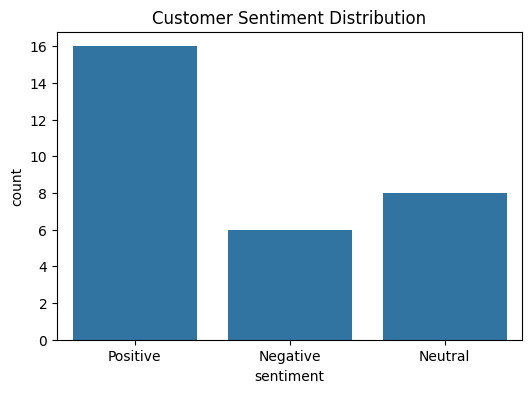

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title("Customer Sentiment Distribution")
plt.show()

In [9]:
def classify_stage(text):
    text = text.lower()

    if "website" in text or "ad" in text:
        return "Awareness"
    elif "compare" in text or "price" in text:
        return "Consideration"
    elif "checkout" in text or "payment" in text:
        return "Purchase"
    elif "support" in text or "help" in text:
        return "Support"
    else:
        return "Retention"

df['journey_stage'] = df['feedback'].apply(classify_stage)
df[['feedback','journey_stage']].head()

,feedback,journey_stage
0,"Saw your Instagram ad and visited the website,...",Awareness
1,Website was easy to navigate but product detai...,Awareness
2,Compared prices with other brands and found yo...,Consideration
3,The checkout process was smooth and payment wo...,Purchase
4,Payment failed twice before order confirmation...,Purchase


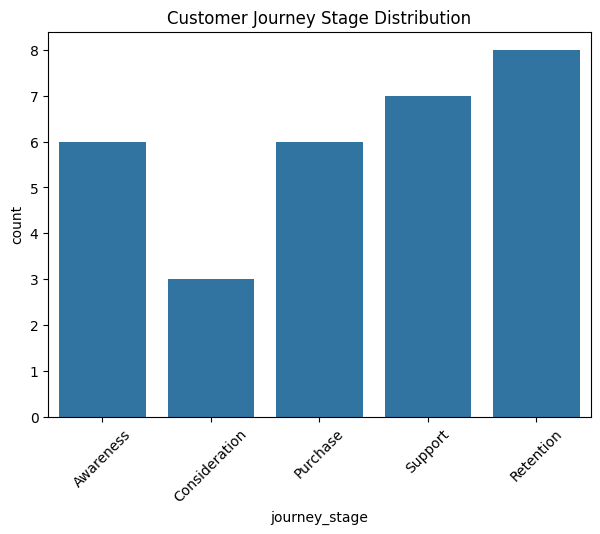

In [10]:
plt.figure(figsize=(7,5))
sns.countplot(x='journey_stage', data=df)
plt.title("Customer Journey Stage Distribution")
plt.xticks(rotation=45)
plt.show()

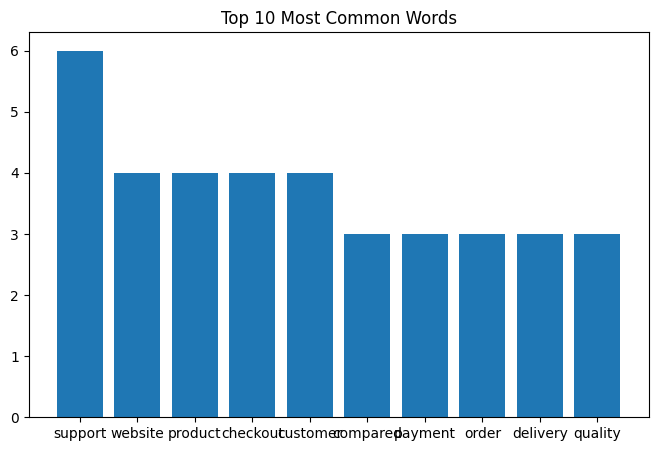

In [11]:
all_words = " ".join(df['cleaned_feedback']).split()

word_freq = Counter(all_words)
common_words = word_freq.most_common(10)

words = [i[0] for i in common_words]
freq = [i[1] for i in common_words]

plt.figure(figsize=(8,5))
plt.bar(words, freq)
plt.title("Top 10 Most Common Words")
plt.show()

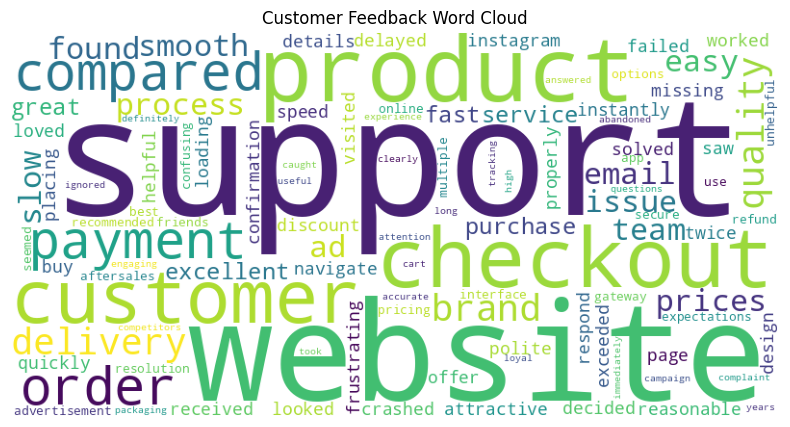

In [12]:
text = " ".join(df['cleaned_feedback'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Customer Feedback Word Cloud")
plt.show()

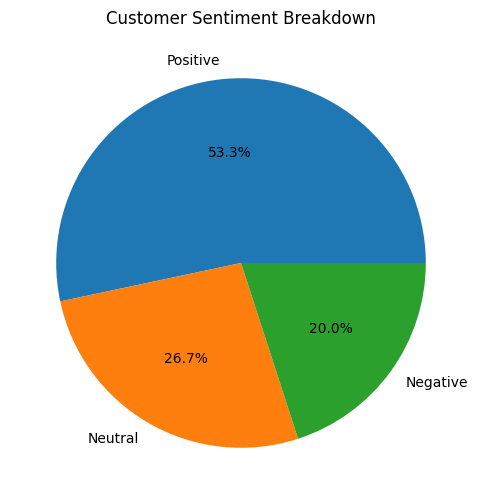

In [13]:
df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title("Customer Sentiment Breakdown")
plt.ylabel("")
plt.show()

In [14]:
print("Total Customers:", len(df))

print("\nSentiment Summary:")
print(df['sentiment'].value_counts())

print("\nJourney Stage Summary:")
print(df['journey_stage'].value_counts())

Total Customers: 30

Sentiment Summary:
sentiment
Positive    16
Neutral      8
Negative     6
Name: count, dtype: int64

Journey Stage Summary:
journey_stage
Retention        8
Support          7
Awareness        6
Purchase         6
Consideration    3
Name: count, dtype: int64


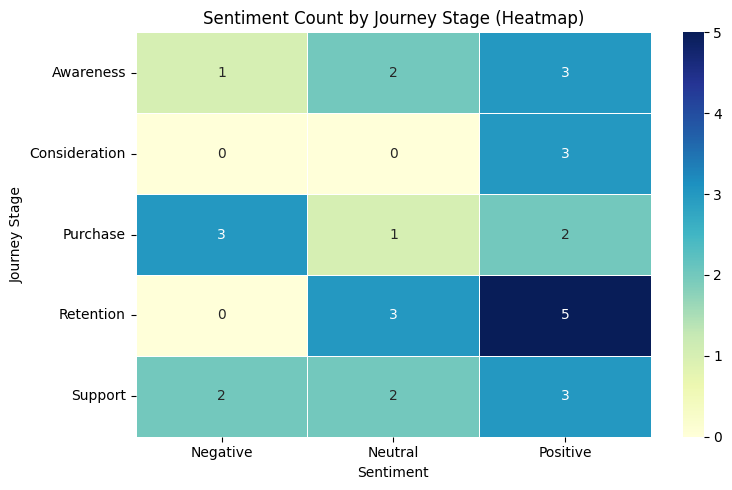

In [15]:
# Graph 1: Heatmap — sentiment count per journey stage
pivot = df.groupby(['journey_stage', 'sentiment']).size().unstack(fill_value=0)
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5)
plt.title("Sentiment Count by Journey Stage (Heatmap)")
plt.ylabel("Journey Stage")
plt.xlabel("Sentiment")
plt.tight_layout()
plt.show()

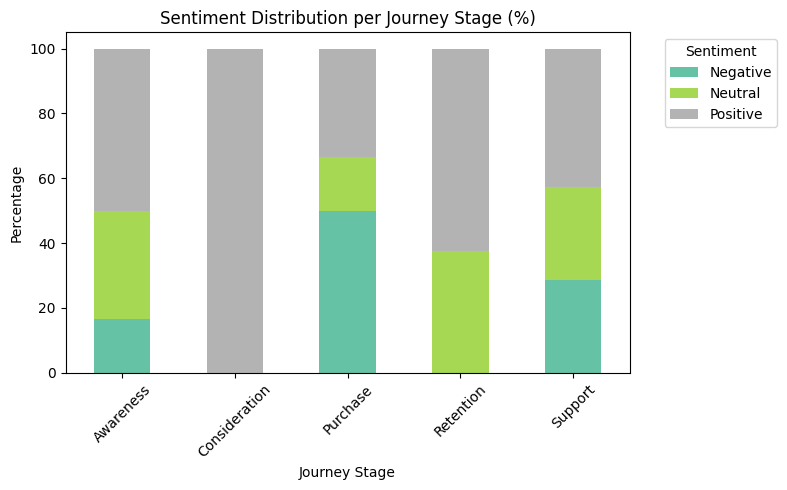

In [16]:
# Graph 2: Stacked bar — sentiment proportions per journey stage
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='Set2')
plt.title("Sentiment Distribution per Journey Stage (%)")
plt.ylabel("Percentage")
plt.xlabel("Journey Stage")
plt.xticks(rotation=45)
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

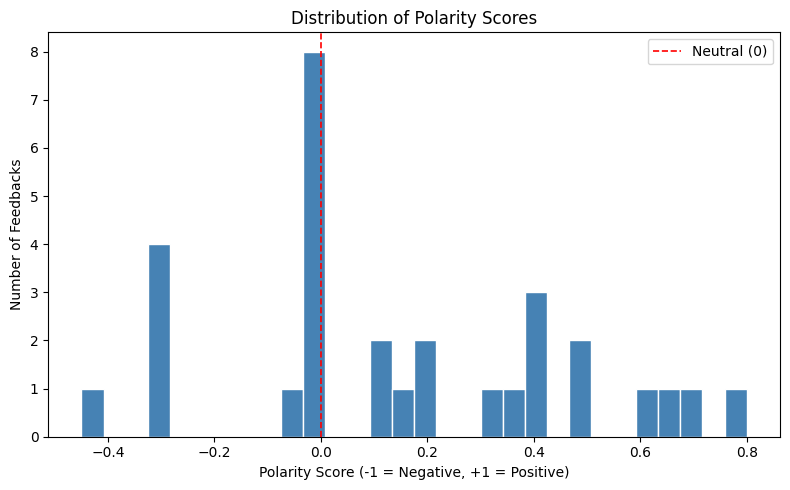

In [17]:
# Graph 3: Distribution of raw polarity scores from TextBlob
df['polarity_score'] = df['cleaned_feedback'].apply(lambda x: TextBlob(x).sentiment.polarity)

plt.figure(figsize=(8, 5))
plt.hist(df['polarity_score'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Neutral (0)')
plt.title("Distribution of Polarity Scores")
plt.xlabel("Polarity Score (-1 = Negative, +1 = Positive)")
plt.ylabel("Number of Feedbacks")
plt.legend()
plt.tight_layout()
plt.show()

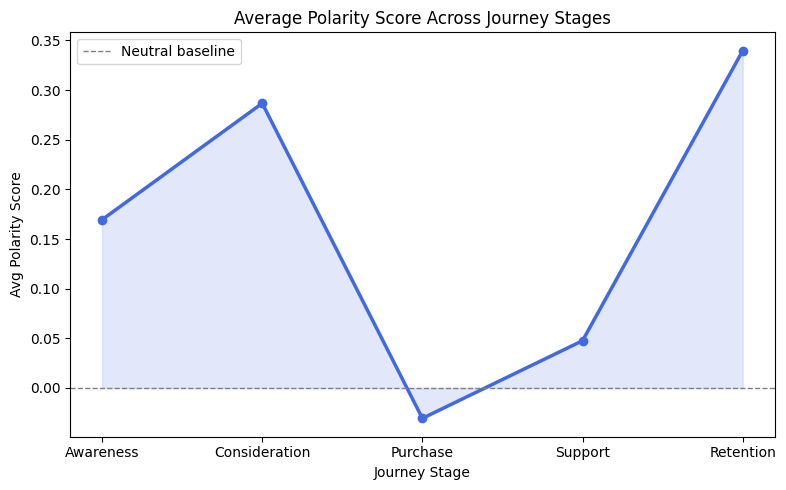

In [18]:
# Graph 4: Line chart — avg polarity score per journey stage
stage_order = ['Awareness', 'Consideration', 'Purchase', 'Support', 'Retention']
avg_polarity = df.groupby('journey_stage')['polarity_score'].mean().reindex(stage_order).dropna()

plt.figure(figsize=(8, 5))
plt.plot(avg_polarity.index, avg_polarity.values, marker='o', linewidth=2.5, color='royalblue')
plt.fill_between(avg_polarity.index, avg_polarity.values, alpha=0.15, color='royalblue')
plt.axhline(0, color='gray', linestyle='--', linewidth=1, label='Neutral baseline')
plt.title("Average Polarity Score Across Journey Stages")
plt.ylabel("Avg Polarity Score")
plt.xlabel("Journey Stage")
plt.legend()
plt.tight_layout()
plt.show()

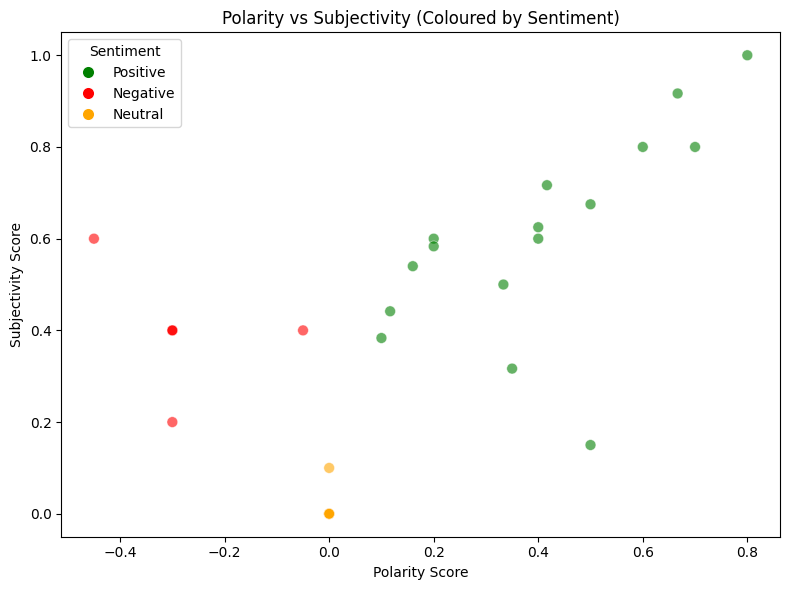

In [19]:
# Graph 5: Scatter — polarity vs subjectivity, coloured by sentiment
df['subjectivity_score'] = df['cleaned_feedback'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

color_map = {'Positive': 'green', 'Negative': 'red', 'Neutral': 'orange'}
colors = df['sentiment'].map(color_map)

plt.figure(figsize=(8, 6))
plt.scatter(df['polarity_score'], df['subjectivity_score'],
            c=colors, alpha=0.6, edgecolors='white', linewidth=0.5, s=60)
plt.title("Polarity vs Subjectivity (Coloured by Sentiment)")
plt.xlabel("Polarity Score")
plt.ylabel("Subjectivity Score")
handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=v,
           markersize=9, label=k) for k, v in color_map.items()]
plt.legend(handles=handles, title="Sentiment")
plt.tight_layout()
plt.show()

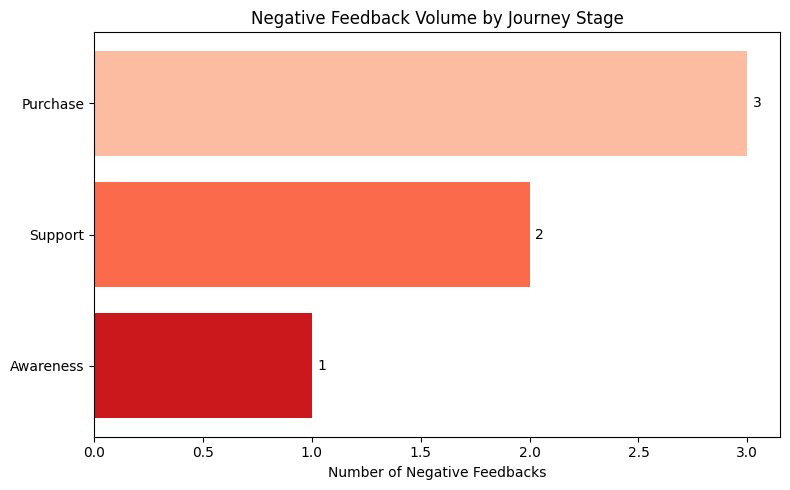

In [20]:
# Graph 6: Horizontal bar funnel — negative feedback count per stage
neg_df = df[df['sentiment'] == 'Negative']
neg_counts = neg_df['journey_stage'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(neg_counts.index, neg_counts.values,
                color=sns.color_palette("Reds_r", len(neg_counts)))
plt.bar_label(bars, padding=4)
plt.title("Negative Feedback Volume by Journey Stage")
plt.xlabel("Number of Negative Feedbacks")
plt.tight_layout()
plt.show()